# Eje 2a — Propiedades: sensibilidad del precio (vanilla)

Derivados Financieros — QUANt UCEMA

Cómo responde el precio de una opción europea (Black-Scholes) cuando cambia un parámetro: $S$, $K$, $T$, $r$, $\sigma$, $q$ (dividendos).

**Plan del notebook:**
1. Setup y precio base
2. Precio vs Spot ($S$)
3. Precio vs Strike ($K$)
4. Precio vs Volatilidad ($\sigma$)
5. Precio vs Tasa ($r$) y Dividendos ($q$)
6. Precio vs Tiempo a vencimiento ($T$)
7. Resumen


## 1) Setup y precio base

Usamos `Codigo.pricing.opcion_europea_bs`. Convención del framework: `tipo='C'` o `'P'`; `div` = yield continuo $q$.


In [1]:
import sys
sys.path.append('../../..')

import numpy as np
import matplotlib.pyplot as plt
from Codigo.pricing import opcion_europea_bs as bs

# Escenario base (ATM, 1 año)
S0, K0, T0, r0, sigma0, q0 = 100.0, 100.0, 1.0, 0.05, 0.25, 0.0

c0 = bs('C', S0, K0, T0, r0, sigma0, q0)
p0 = bs('P', S0, K0, T0, r0, sigma0, q0)
print(f'Call ATM: {c0:.4f}')
print(f'Put  ATM: {p0:.4f}')
print(f'Call - Put: {c0 - p0:.4f}  |  S*e^(-qT) - K*e^(-rT): {S0*np.exp(-q0*T0) - K0*np.exp(-r0*T0):.4f}')


Call ATM: 12.3360
Put  ATM: 7.4589
Call - Put: 4.8771  |  S*e^(-qT) - K*e^(-rT): 4.8771


## 2) Precio vs Spot ($S$)

- Call: creciente en $S$ (más derecho a comprar barato).
- Put: decreciente en $S$.
- En $T\to 0$ el precio se acerca al **payoff** (valor intrínseco).


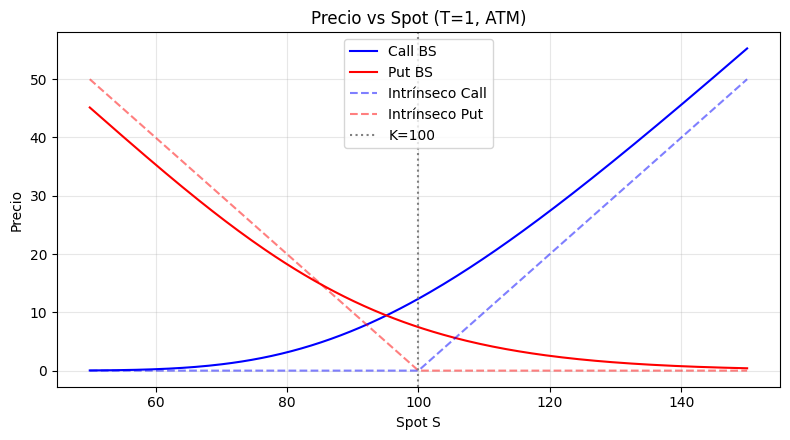

In [2]:
S_grid = np.linspace(50, 150, 200)
calls = [bs('C', S, K0, T0, r0, sigma0, q0) for S in S_grid]
puts  = [bs('P', S, K0, T0, r0, sigma0, q0) for S in S_grid]
intr_c = np.maximum(S_grid - K0, 0)
intr_p = np.maximum(K0 - S_grid, 0)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(S_grid, calls, 'b-', label='Call BS')
ax.plot(S_grid, puts, 'r-', label='Put BS')
ax.plot(S_grid, intr_c, 'b--', alpha=0.5, label='Intrínseco Call')
ax.plot(S_grid, intr_p, 'r--', alpha=0.5, label='Intrínseco Put')
ax.axvline(K0, color='gray', ls=':', label=f'K={K0:.0f}')
ax.set_xlabel('Spot S'); ax.set_ylabel('Precio')
ax.set_title('Precio vs Spot (T=1, ATM)')
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


## 3) Precio vs Strike ($K$)

Subir el strike abarata el call y encarece el put (todo lo demás fijo).


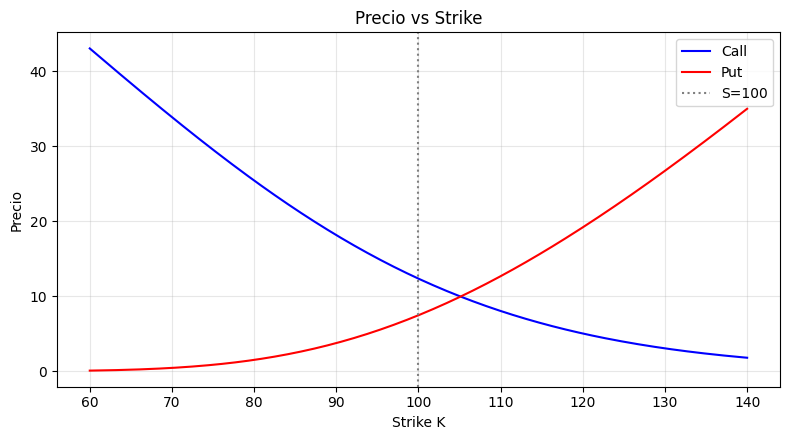

In [3]:
K_grid = np.linspace(60, 140, 200)
calls_k = [bs('C', S0, K, T0, r0, sigma0, q0) for K in K_grid]
puts_k  = [bs('P', S0, K, T0, r0, sigma0, q0) for K in K_grid]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(K_grid, calls_k, 'b-', label='Call')
ax.plot(K_grid, puts_k, 'r-', label='Put')
ax.axvline(S0, color='gray', ls=':', label=f'S={S0:.0f}')
ax.set_xlabel('Strike K'); ax.set_ylabel('Precio')
ax.set_title('Precio vs Strike')
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


## 4) Precio vs Volatilidad ($\sigma$)

Más volatilidad $\Rightarrow$ opciones más caras (call y put). Es la intuición detrás de **Vega $> 0$** (se formaliza en el eje de Griegas).


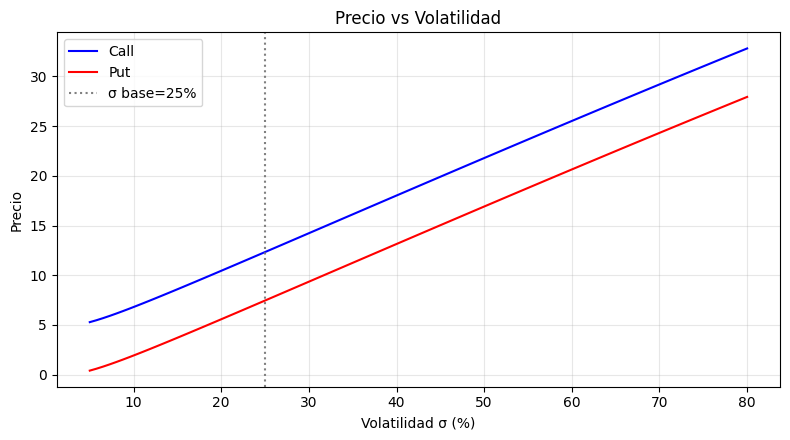

In [4]:
sig_grid = np.linspace(0.05, 0.80, 100)
calls_v = [bs('C', S0, K0, T0, r0, sig, q0) for sig in sig_grid]
puts_v  = [bs('P', S0, K0, T0, r0, sig, q0) for sig in sig_grid]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(sig_grid * 100, calls_v, 'b-', label='Call')
ax.plot(sig_grid * 100, puts_v, 'r-', label='Put')
ax.axvline(sigma0 * 100, color='gray', ls=':', label=f'σ base={sigma0*100:.0f}%')
ax.set_xlabel('Volatilidad σ (%)'); ax.set_ylabel('Precio')
ax.set_title('Precio vs Volatilidad')
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


## 5) Precio vs Tasa ($r$) y Dividendos ($q$)

Intuición (europeas con yield continuo):
- Sube $r$: el call suele **subir**, el put **bajar** (financiar el strike / carry).
- Sube $q$: el call suele **bajar**, el put **subir** (el subyacente “paga” dividendos).


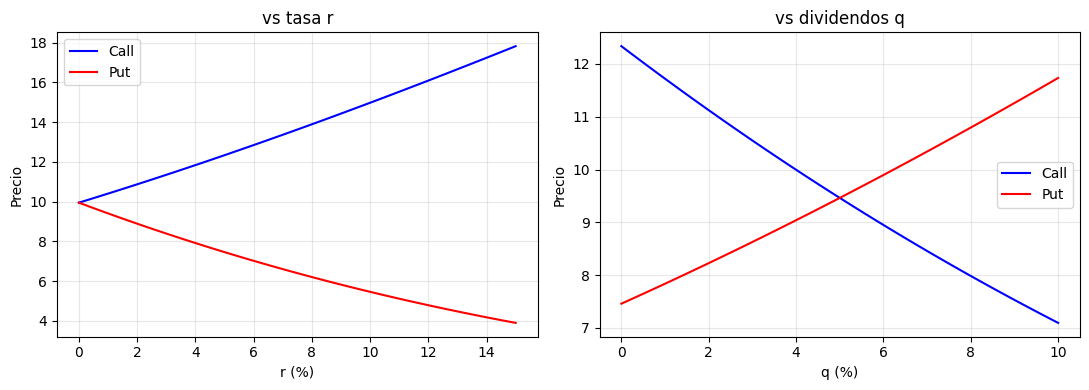

In [5]:
r_grid = np.linspace(0.0, 0.15, 80)
q_grid = np.linspace(0.0, 0.10, 80)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(r_grid * 100, [bs('C', S0, K0, T0, r, sigma0, q0) for r in r_grid], 'b-', label='Call')
axes[0].plot(r_grid * 100, [bs('P', S0, K0, T0, r, sigma0, q0) for r in r_grid], 'r-', label='Put')
axes[0].set_xlabel('r (%)'); axes[0].set_ylabel('Precio'); axes[0].set_title('vs tasa r')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(q_grid * 100, [bs('C', S0, K0, T0, r0, sigma0, q) for q in q_grid], 'b-', label='Call')
axes[1].plot(q_grid * 100, [bs('P', S0, K0, T0, r0, sigma0, q) for q in q_grid], 'r-', label='Put')
axes[1].set_xlabel('q (%)'); axes[1].set_ylabel('Precio'); axes[1].set_title('vs dividendos q')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


## 6) Precio vs Tiempo a vencimiento ($T$)

Con $r,q,\sigma$ fijos, más tiempo suele aumentar el valor temporal (pero hay matices en deep ITM puts con tasas). Compará $T$ corto vs largo vs intrínseco.


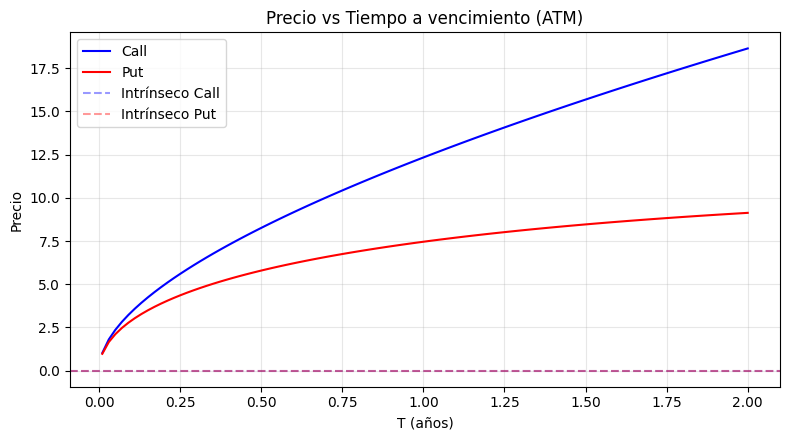

In [6]:
T_grid = np.linspace(0.01, 2.0, 100)
calls_t = [bs('C', S0, K0, T, r0, sigma0, q0) for T in T_grid]
puts_t  = [bs('P', S0, K0, T, r0, sigma0, q0) for T in T_grid]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(T_grid, calls_t, 'b-', label='Call')
ax.plot(T_grid, puts_t, 'r-', label='Put')
ax.axhline(max(S0 - K0, 0), color='b', ls='--', alpha=0.4, label='Intrínseco Call')
ax.axhline(max(K0 - S0, 0), color='r', ls='--', alpha=0.4, label='Intrínseco Put')
ax.set_xlabel('T (años)'); ax.set_ylabel('Precio')
ax.set_title('Precio vs Tiempo a vencimiento (ATM)')
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


## Resumen

- El precio BS de una vanilla es función de $(S,K,T,r,\sigma,q)$.
- **$S\uparrow$**: call $\uparrow$, put $\downarrow$. **$K\uparrow$**: al revés.
- **$\sigma\uparrow$**: call y put $\uparrow$ (valor temporal / incertidumbre).
- **$r\uparrow$ / $q\uparrow$**: efectos opuestos en call vs put (carry).
- La diferencia precio − intrínseco es el **valor temporal** (se profundiza con Griegas).

**Para clase:** abrir también la página *Propiedades de opciones* de la webapp UCEMA QUANT y variar el mismo parámetro en vivo.
